# 📊 Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    r"D:\GitHub Repositories\Uber-Ride-Sharing-Analytics\datasets\feature_engineered_uber.csv"
)
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [3]:
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_year,pickup_day_name,pickup_month_name,day_type
0,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,19,7,5,2015,Thursday,May,Weekday
1,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,20,17,7,2009,Friday,July,Weekday
2,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,21,24,8,2009,Monday,August,Weekday
3,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,8,26,6,2009,Friday,June,Weekday
4,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,17,28,8,2014,Thursday,August,Weekday


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199969 entries, 0 to 199968
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   key                199969 non-null  object             
 1   fare_amount        199969 non-null  float64            
 2   pickup_datetime    199969 non-null  datetime64[ns, UTC]
 3   pickup_longitude   199969 non-null  float64            
 4   pickup_latitude    199969 non-null  float64            
 5   dropoff_longitude  199969 non-null  float64            
 6   dropoff_latitude   199969 non-null  float64            
 7   passenger_count    199969 non-null  int64              
 8   pickup_hour        199969 non-null  int64              
 9   pickup_day         199969 non-null  int64              
 10  pickup_month       199969 non-null  int64              
 11  pickup_year        199969 non-null  int64              
 12  pickup_day_name    199969 non-

In [5]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_hour,pickup_day,pickup_month,pickup_year
count,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000,199969.000000
mean,11.362258,-72.501654,39.917862,-72.511845,39.922160,1.683471,13.491531,15.704994,6.282009,2011.742395
std,9.897235,10.450416,6.130682,10.411390,6.117288,1.306938,6.515414,8.687527,3.438956,1.856356
min,0.000000,-93.824668,-74.015515,-75.458979,-74.015750,0.000000,0.000000,1.000000,1.000000,2009.000000
25%,6.000000,-73.992065,40.734792,-73.991407,40.733824,1.000000,9.000000,8.000000,3.000000,2010.000000
50%,8.500000,-73.981822,40.752591,-73.980092,40.753042,1.000000,14.000000,16.000000,6.000000,2012.000000
75%,12.500000,-73.967155,40.767157,-73.963658,40.768001,2.000000,19.000000,23.000000,9.000000,2013.000000
max,499.000000,40.808425,48.018760,40.831932,45.031598,6.000000,23.000000,31.000000,12.000000,2015.000000


In [6]:
df.columns

Index(['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count', 'pickup_hour', 'pickup_day', 'pickup_month',
       'pickup_year', 'pickup_day_name', 'pickup_month_name', 'day_type'],
      dtype='object')

In [7]:
df['fare_amount'].describe()

count    199969.000000
mean         11.362258
std           9.897235
min           0.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

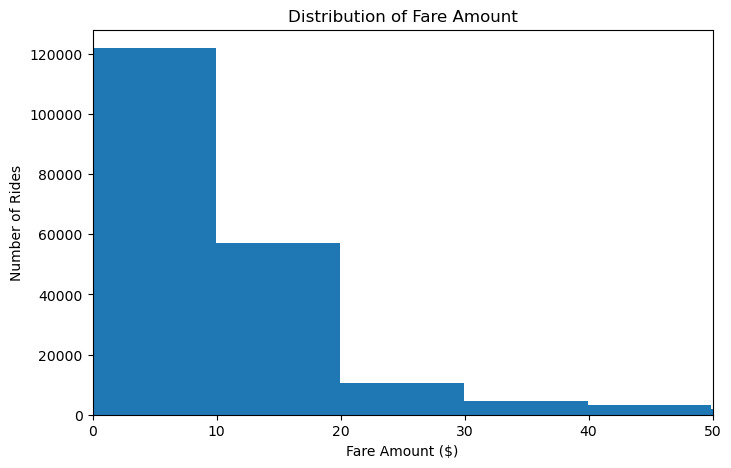

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df['fare_amount'], bins=50)

plt.xlim(0,50)

plt.title("Distribution of Fare Amount")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Rides")

plt.show()

### Analysis: Fare Amount Distribution

**Observation:**
- Most Uber rides have fares between **$0 and $10**.
- The number of rides decreases as the fare amount increases.
- Only a small number of rides have fares above **$30**.

**Business Insight:**
The fare distribution is **right-skewed**, indicating that most Uber trips are low-cost, while high-fare trips are relatively rare.

In [9]:
hourly_rides = df['pickup_hour'].value_counts().sort_index()
hourly_rides

pickup_hour
0      7842
1      5908
2      4422
3      3254
4      2364
5      1965
6      4139
7      7229
8      9072
9      9339
10     8942
11     9420
12     9923
13    10023
14     9748
15     9613
16     8312
17     9758
18    12071
19    12603
20    11754
21    11444
22    11022
23     9802
Name: count, dtype: int64

### Analysis: Pickup Hour

**Observation:**
- The highest number of rides occurred at **7 PM (19:00)**.
- The lowest number of rides occurred at **5 AM**.
- Ride demand increases during the morning (7 AM–12 PM) and reaches another peak during the evening (5 PM–10 PM).

**Business Insight:**
The evening peak likely reflects commuters returning home from work and people traveling for shopping, dining, or other evening activities. Uber can use this information to allocate more drivers during peak hours and improve service availability.

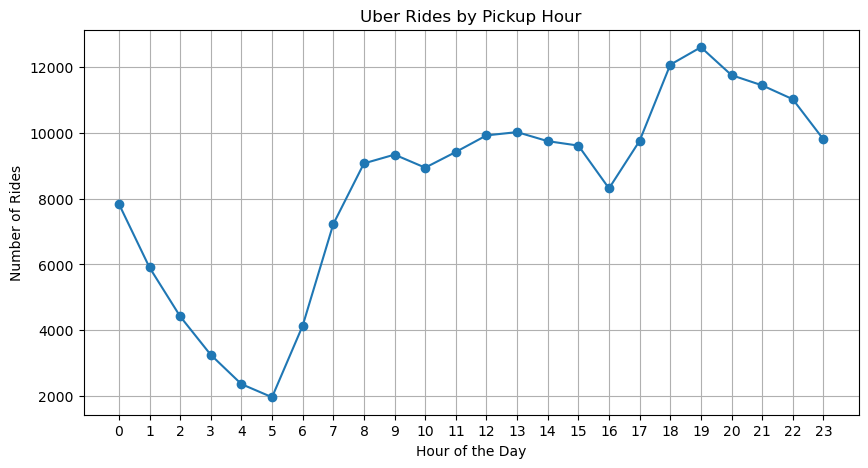

In [10]:
plt.figure(figsize=(10,5))

plt.plot(hourly_rides, marker='o')

plt.title("Uber Rides by Pickup Hour")
plt.xlabel("Hour of the Day")
plt.ylabel("Number of Rides")

plt.xticks(range(24))

plt.grid(True)

plt.show()

### Analysis: Pickup Hour

**Observation:**
- Ride demand is lowest at **5 AM**.
- Demand starts increasing after **6 AM**.
- A morning peak is observed between **8 AM and 1 PM**.
- The highest demand occurs at **7 PM (19:00)**.
- Ride demand gradually decreases after **8 PM**.

**Business Insight:**
Uber should allocate more drivers during the evening peak, especially around **7 PM**, to reduce passenger wait times and improve ride availability. Early morning hours have the lowest demand and may require fewer active drivers.

In [11]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_rides = (df['pickup_day_name'].value_counts().reindex(day_order))
weekday_rides

pickup_day_name
Monday       25242
Tuesday      28120
Wednesday    29031
Thursday     30018
Friday       30873
Saturday     30246
Sunday       26439
Name: count, dtype: int64

### Analysis: Ride Demand by Weekday

**Observation:**
- **Friday** has the highest number of rides.
- **Monday** has the lowest number of rides.
- Ride demand generally increases from Monday to Friday.
- **Saturday** also experiences high demand, while **Sunday** shows a decline.

**Business Insight:**
The high demand on Friday likely reflects the combination of work commutes and the beginning of weekend activities. Uber can increase driver availability on Friday and Saturday to better meet customer demand.

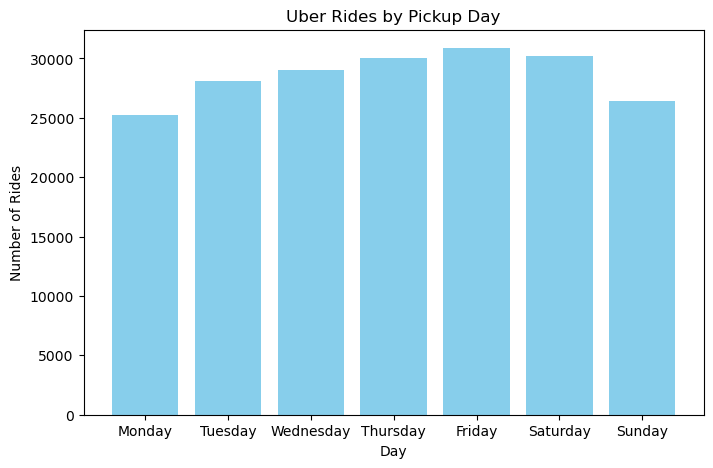

In [13]:
plt.figure(figsize=(8,5))

plt.bar(weekday_rides.index, weekday_rides.values, color='skyblue')

plt.title("Uber Rides by Pickup Day")
plt.xlabel("Day")
plt.ylabel("Number of Rides")

plt.show()

### Analysis: Uber Rides by Pickup Day

**Observation:**
- **Friday** has the highest number of Uber rides (**30,873**).
- **Monday** has the lowest number of Uber rides (**25,242**).
- Ride demand gradually increases from **Monday to Friday**.
- **Saturday** also has high demand, while **Sunday** shows a noticeable decline.

**Business Insight:**
- Friday is the busiest day, likely because people finish their workweek and travel for shopping, dining, entertainment, or weekend activities.
- Uber should increase driver availability on **Friday** and **Saturday** to meet the higher customer demand.
- Since Monday has the lowest demand, fewer drivers may be required compared to the end of the week.

In [14]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_rides = (df['pickup_month_name'].value_counts().reindex(month_order))
monthly_rides

pickup_month_name
January      17667
February     16689
March        18756
April        18605
May          18853
June         17784
July         15093
August       14220
September    15266
October      16211
November     15310
December     15515
Name: count, dtype: int64

### Analysis: Uber Rides by Pickup Month

**Observation:**
- **May** has the highest number of Uber rides (**18,853**).
- **August** has the lowest number of Uber rides (**14,220**).
- Ride demand generally increases from **January to May** and then decreases in the following months.

**Business Insight:**
Ride demand may be higher in **May** due to favorable weather, vacations, tourism, or seasonal travel. Uber can monitor these trends to improve driver allocation and operational planning during high-demand months.

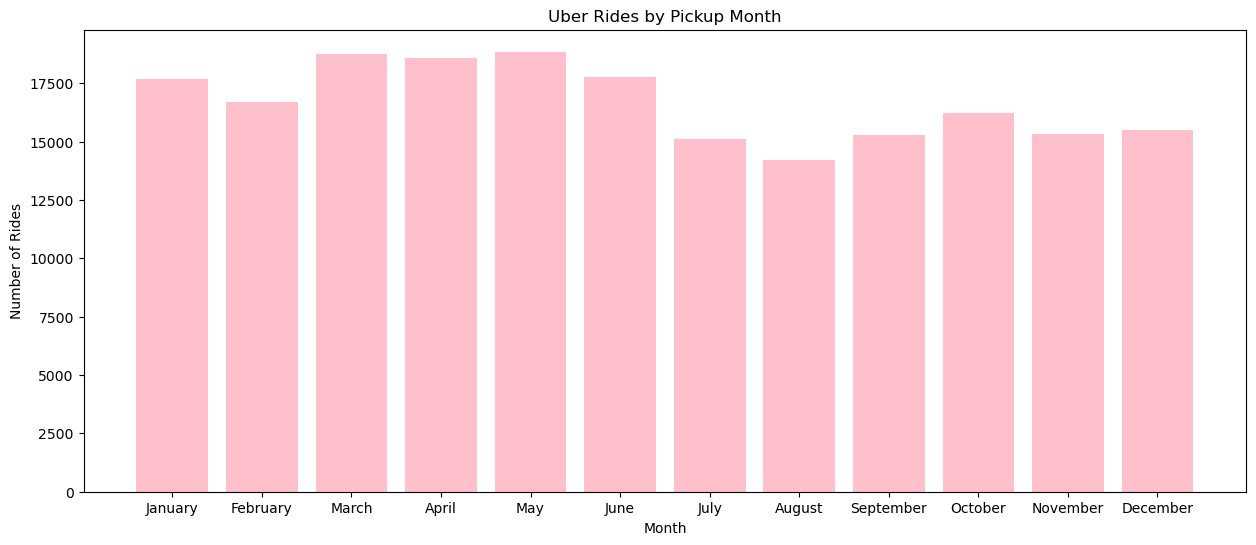

In [26]:
plt.figure(figsize=(15,6))

plt.bar(monthly_rides.index, monthly_rides.values, color='pink')
plt.title("Uber Rides by Pickup Month")
plt.xlabel("Month")
plt.ylabel("Number of Rides")

plt.show()

### Analysis: Uber Rides by Pickup Month

**Observation:**
- **May** has the highest number of Uber rides (**18,853**).
- **August** has the lowest number of Uber rides (**14,220**).
- Ride demand generally increases from **January to May** and then gradually decreases in the following months.

**Business Insight:**
The higher ride demand in **May** may be influenced by favorable weather, tourism, vacations, or seasonal travel. Since **August** has the lowest demand, Uber could consider promotional campaigns or discounts during this month to encourage more bookings and improve revenue.

In [32]:
passenger_rides = (df['passenger_count'].value_counts().sort_index()) 
passenger_rides

passenger_count
0       708
1    138407
2     29425
3      8878
4      4275
5     14005
6      4271
Name: count, dtype: int64

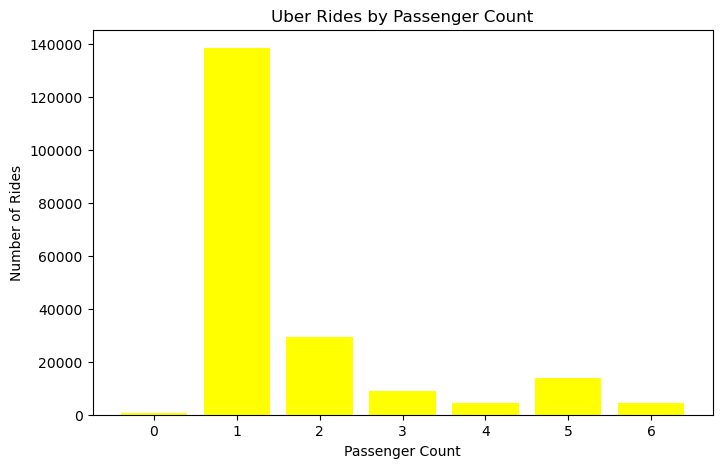

In [35]:
plt.figure(figsize=(8,5))

plt.bar(passenger_rides.index, passenger_rides.values, color='yellow')

plt.title("Uber Rides by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Rides")

plt.show()

### Analysis: Uber Rides by Passenger Count

**Observation:**
- Most Uber rides are taken by **1 passenger** (138,407 rides), representing about **70%** of all trips.
- **2-passenger** rides are the second most common.
- Rides with **4 to 6 passengers** are much less frequent.
- The dataset also contains **708 rides with 0 passengers**, which may indicate a data quality issue or a special case and should be documented.

**Business Insight:**
Since the majority of Uber trips are solo rides, Uber should focus on maintaining fast service and driver availability for individual travelers. To increase group travel, Uber could introduce promotions or discounts for shared and multi-passenger rides.

In [45]:
pickup_map = df[
    (df['pickup_longitude'].between(-75, -72)) &
    (df['pickup_latitude'].between(40, 42))
]

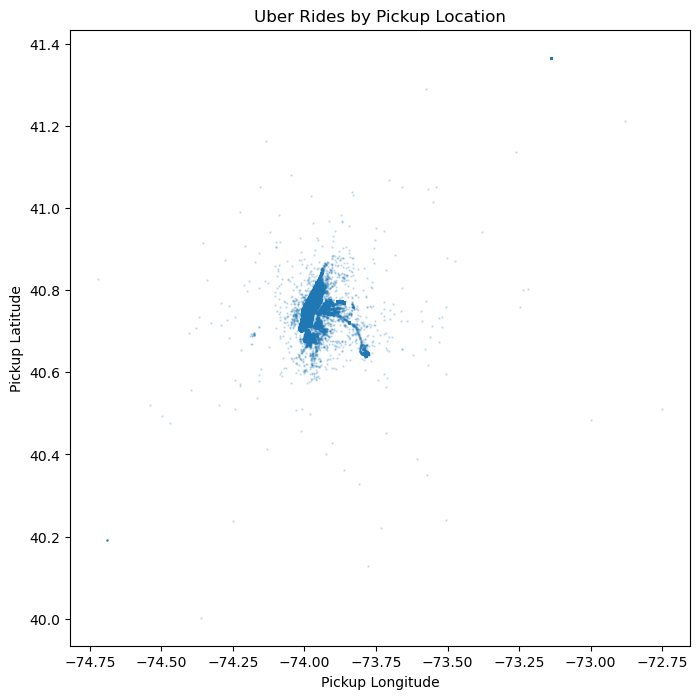

In [47]:
plt.figure(figsize=(8,8))

plt.scatter(
    pickup_map['pickup_longitude'],
    pickup_map['pickup_latitude'],
    alpha=0.2,
    s=0.5
)

plt.title("Uber Rides by Pickup Location")
plt.xlabel("Pickup Longitude")
plt.ylabel("Pickup Latitude")

plt.show()

### Analysis: Geographic Distribution of Pickup Locations

**Observation:**
- Most pickup locations are concentrated around longitude **-74** and latitude **40.7–40.85**.
- A dense cluster of points indicates areas with high ride demand.
- A few isolated points appear outside the main cluster, representing less common pickup locations or outliers.

**Business Insight:**
Uber should allocate more drivers to the high-density pickup areas to reduce customer waiting time and improve service availability. Less crowded regions may require fewer active drivers.

In [49]:
dropoff_map = df[
    (df['dropoff_longitude'].between(-75, -72)) &
    (df['dropoff_latitude'].between(40, 42))
]

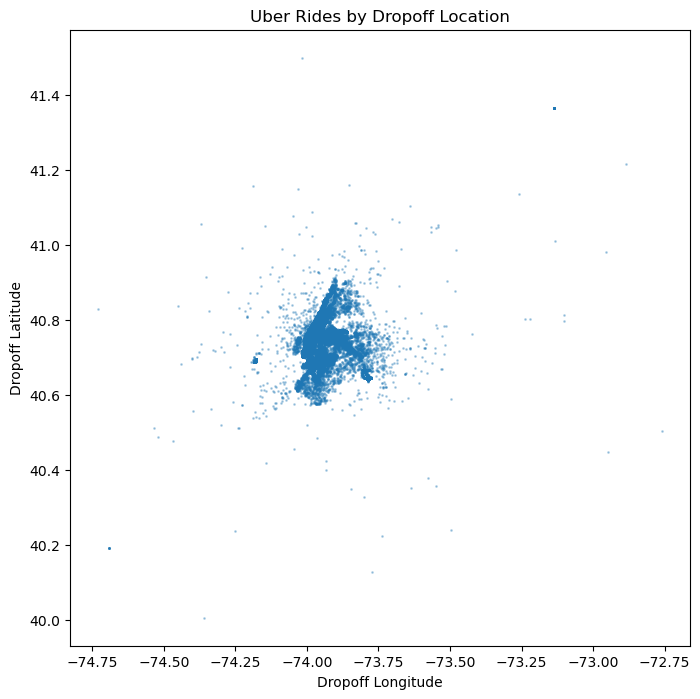

In [50]:
plt.figure(figsize=(8,8))

plt.scatter(
    dropoff_map['dropoff_longitude'],
    dropoff_map['dropoff_latitude'],
    alpha=0.3,
    s=1
)

plt.title("Uber Rides by Dropoff Location")
plt.xlabel("Dropoff Longitude")
plt.ylabel("Dropoff Latitude")

plt.show()

### Analysis: Geographic Distribution of Dropoff Locations

**Observation:**
- Most dropoff locations are concentrated around longitude **-74** and latitude **40.7–40.85**.
- The dropoff pattern is very similar to the pickup distribution, indicating that most trips occur within the same urban area.
- A few scattered points represent less common destinations or outlier locations.

**Business Insight:**
Since both pickup and dropoff locations are concentrated in the same region, Uber should maintain strong driver availability in these high-demand urban areas to improve ride efficiency and reduce waiting times.

### Pickup vs Dropoff Comparison

- Pickup and dropoff locations show very similar geographic distributions.
- Both are highly concentrated around the city center.
- This suggests that the majority of Uber trips occur within the same metropolitan area rather than long-distance travel.

# Final Business Insights Summary

Based on the Exploratory Data Analysis (EDA), the following key business insights were identified:

### 1. Fare Analysis
- Most Uber rides have a fare below **$20**, indicating that customers primarily use Uber for short-distance trips.
- A small number of high-fare rides exist but are relatively rare.

### 2. Peak Ride Hours
- Ride demand is highest during the **evening hours (around 7 PM)**.
- Early morning hours have the lowest ride demand.
- Uber should allocate more drivers during evening peak hours to reduce passenger waiting time.

### 3. Weekly Ride Pattern
- **Friday** records the highest number of rides, while **Monday** has the lowest.
- Demand gradually increases toward the weekend, suggesting higher travel activity on Fridays.

### 4. Monthly Ride Pattern
- **May** has the highest ride demand, whereas **August** records the lowest.
- Seasonal trends may influence customer travel behavior and ride demand.

### 5. Passenger Count Analysis
- Most rides involve **one passenger**, showing that Uber is mainly used for individual travel.
- A small number of rides contain zero passengers, which may represent data-entry errors or special ride cases.

### 6. Geographic Analysis
- Pickup and dropoff locations are highly concentrated around the city center.
- High-density areas indicate regions with the greatest ride demand.
- Uber should position more drivers in these locations to improve ride availability and reduce waiting time.

## Overall Conclusion

The EDA reveals clear patterns in customer behavior, ride demand, travel timing, passenger preferences, and geographic distribution. These insights can help Uber optimize driver allocation, improve customer experience, and support better business decision-making.

In [53]:
df = df[
    (df['pickup_longitude'].between(-75, -72)) &
    (df['pickup_latitude'].between(40, 42)) &
    (df['dropoff_longitude'].between(-75, -72)) &
    (df['dropoff_latitude'].between(40, 42))
]

In [55]:
df['pickup_longitude'].min(), df['pickup_longitude'].max()

(np.float64(-74.719883), np.float64(-72.750302))

In [56]:
df['pickup_latitude'].min(), df['pickup_latitude'].max()

(np.float64(40.002405), np.float64(41.366138))

In [57]:
df.to_csv(r"D:\GitHub Repositories\Uber-Ride-Sharing-Analytics\datasets\uber_final_processed.csv", index=False)